<a href="https://colab.research.google.com/github/Prabhavathi-Ai/aiml_ioc/blob/main/StudentPassFail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

# List the files in the downloaded dataset directory
files = os.listdir(path)
print("Files in dataset path:", files)

# Assuming there is a CSV file, we will load the first one found
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {csv_files[0]} into df!")
    print(df.head())
else:
    print("No CSV files found in the dataset directory.")

Files in dataset path: ['student-mat-pass-or-fail.csv']
Successfully loaded student-mat-pass-or-fail.csv into df!
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  traveltime  \
0       1    1   18        1        0        0     4     4           2   
1       1    1   17        1        0        1     1     1           1   
2       1    1   15        1        1        1     1     1           1   
3       1    1   15        1        0        1     4     2           1   
4       1    1   16        1        0        1     3     3           1   

   studytime  ...  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3  \
0          2  ...         3      4     1     1       3         6   5   6   6   
1          2  ...         3      3     1     1       3         4   5   5   6   
2          2  ...         3      2     2     3       3        10   7   8  10   
3          3  ...         2      2     1     1       5         2  15  14  15   
4          2  ...         3      2     1 

### Tokenizing Categorical Features in the Student Dataset

Let's apply tokenization (indexing) to the categorical features in our `student-mat-pass-or-fail.csv` dataset.

In [ ]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import StringLookup

# 1. Resolve dataset directory using the global 'path' variable
try:
    # Since 'path' was defined in a previous cell, we can access it directly
    dataset_dir = path
    csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]
    file_path = os.path.join(dataset_dir, csv_files[0])
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {csv_files[0]}!")
except NameError:
    print("Warning: 'path' variable not found globally. Re-running download...")
    import kagglehub
    dataset_dir = kagglehub.dataset_download("ouline/student-mat-pass-or-fail")
    csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]
    file_path = os.path.join(dataset_dir, csv_files[0])
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {csv_files[0]} after downloading!")

# 2. Inspect unique values for categorical columns
print("Unique values in 'school':", df['school'].unique())
print("Unique values in 'sex':", df['sex'].unique())

# 3. Convert column data to string type for StringLookup tokenization
school_strings = df['school'].astype(str).values

# 4. Initialize and adapt the StringLookup layer
school_lookup = StringLookup(output_mode='int')
school_lookup.adapt(school_strings)

# Tokenize/index the school values
tokenized_schools = school_lookup(school_strings)

print("\nVocabulary for 'school' column:", school_lookup.get_vocabulary())
print("First 10 tokenized school indices:", tokenized_schools[:10].numpy())

Using Colab cache for faster access to the 'student-mat-pass-or-fail' dataset.
Successfully loaded student-mat-pass-or-fail.csv after downloading!
Unique values in 'school': [1 0]
Unique values in 'sex': [1 0]

Vocabulary for 'school' column: ['[UNK]', np.str_('1'), np.str_('0')]
First 10 tokenized school indices: [1 1 1 1 1 1 1 1 1 1]


In [ ]:

import kagglehub
path = kagglehub.dataset_download("ouline/student-mat-pass-or-fail")

100%|██████████| 5.50k/5.50k [00:00<00:00, 6.53MB/s]

Extracting files...


### Understanding Embeddings and Tokenization

To represent words or discrete categorical tokens as dense vectors, we go through two main steps:
1. **Tokenization (and Indexing):** Mapping each unique token (word or category) to a unique integer index.
2. **Embedding:** Mapping each integer index to a dense vector of continuous values (weights). These weights are learned during model training to capture semantic relationships. Tokens with similar contexts or meanings will end up closer to each other in the vector space.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import StringLookup, Embedding
import numpy as np

# 1. Sample text tokens (e.g., student schools or neighborhood types)
tokens = ["GP", "MS", "GP", "GP", "MS", "Unknown"]

# 2. Map string tokens to vocabulary integer indices
# we set output_mode='int' to map each string to an integer
vocab_layer = StringLookup(output_mode='int')
vocab_layer.adapt(tokens)

integer_indices = vocab_layer(tokens)
unique_vocab = vocab_layer.get_vocabulary()

print("Vocabulary:", unique_vocab)
print("Original Tokens:", tokens)
print("Mapped Integer Indices:", integer_indices.numpy())

# 3. Define an Embedding Layer
# input_dim: size of the vocabulary
# output_dim: size of the dense embedding vector (e.g., 4 dimensions)
embedding_dim = 4
embedding_layer = Embedding(input_dim=len(unique_vocab), output_dim=embedding_dim)

# 4. Convert indices to embeddings
embeddings = embedding_layer(integer_indices)

print("\nGenerated Embeddings:")
for token, idx, emb in zip(tokens, integer_indices.numpy(), embeddings.numpy()):
    print(f"Token: '{token}' (Index: {idx}) -> Embedding: {emb}")

Vocabulary: ['[UNK]', np.str_('GP'), np.str_('MS'), np.str_('Unknown')]
Original Tokens: ['GP', 'MS', 'GP', 'GP', 'MS', 'Unknown']
Mapped Integer Indices: [1 2 1 1 2 3]

Generated Embeddings:
Token: 'GP' (Index: 1) -> Embedding: [0.00315273 0.0080734  0.04034736 0.04624202]
Token: 'MS' (Index: 2) -> Embedding: [-0.04116852 -0.01665661  0.03040114 -0.01078763]
Token: 'GP' (Index: 1) -> Embedding: [0.00315273 0.0080734  0.04034736 0.04624202]
Token: 'GP' (Index: 1) -> Embedding: [0.00315273 0.0080734  0.04034736 0.04624202]
Token: 'MS' (Index: 2) -> Embedding: [-0.04116852 -0.01665661  0.03040114 -0.01078763]
Token: 'Unknown' (Index: 3) -> Embedding: [ 0.03300067  0.00290637  0.01949897 -0.02598706]


### Building an In-Memory Vector Database (Semantic Search)

A vector database works by storing high-dimensional vector representations (embeddings) of text chunks and allowing us to retrieve the most similar chunks using distance metrics like **Cosine Similarity**.

Let's build a simple in-memory vector database using `numpy` and `TensorFlow` embeddings. We will index multiple sentences and search for the most relevant ones given a user query.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding

# 1. Documents to store in our Vector Database
documents = [
    "The student returned home from shooting.",
    "A cold wind blew from the east.",
    "The weather was fine and still initially.",
    "The student was terribly hungry on Good Friday.",
    "He did not want to go home to his family."
]

# 2. Set up Vectorization & Embedding Layers
vectorizer = TextVectorization(standardize='lower_and_strip_punctuation')
vectorizer.adapt(documents)

vocab_size = len(vectorizer.get_vocabulary())
embedding_dim = 8

embedding_layer = Embedding(input_dim=vocab_size, output_dim=embedding_dim)

# 3. Create document embeddings (Sentence Embedding = average of word embeddings)
def embed_text(text_list):
    indices = vectorizer(text_list)
    word_embeddings = embedding_layer(indices)
    # Compute mean vector across words to get a single vector per document
    sentence_embeddings = tf.reduce_mean(word_embeddings, axis=1)
    return sentence_embeddings.numpy()

# Index the documents in our database
doc_embeddings = embed_text(documents)
print(f"Database initialized with {len(documents)} documents.")
print("Embedding shape per document:", doc_embeddings[0].shape)

Database initialized with 5 documents.
Embedding shape per document: (8,)


In [ ]:
# 4. Search function using Cosine Similarity
def search_vector_db(query, documents, doc_embeddings, top_k=2):
    # Embed the query
    query_embedding = embed_text([query])[0]

    # Normalize vectors to calculate Cosine Similarity
    query_norm = query_embedding / np.linalg.norm(query_embedding)
    doc_norms = doc_embeddings / np.linalg.norm(doc_embeddings, axis=1, keepdims=True)

    # Compute similarities (dot product of normalized vectors)
    similarities = np.dot(doc_norms, query_norm)

    # Sort and get top-K matches
    top_indices = np.argsort(similarities)[::-1][:top_k]

    print(f"Query: '{query}'\n")
    print("Search Results:")
    for idx in top_indices:
        print(f"- Score: {similarities[idx]:.4f} | Document: \"{documents[idx]}\"")

# Run a search query
search_vector_db("freezing wind blowing east", documents, doc_embeddings, top_k=2)

Query: 'freezing wind blowing east'

Search Results:
- Score: 0.7583 | Document: "The weather was fine and still initially."
- Score: 0.6366 | Document: "A cold wind blew from the east."


### 🎨 Visual Guide: From Text to Search (Vector DB Pipeline)

To help visualize how the vector database code above actually works, here are three visual flows representing each critical phase of our pipeline:

---

#### 1. Tokenization & Embedding (Word Level)
Before a computer can process words, we map them into a geometric coordinate space.

```
Input Text:       "cold wind"
                    ↓
Tokenization:     ["cold", "wind"]            (Split & clean punctuation)
                    ↓
Indexing:         [ 15,    16 ]               (Map to integer IDs from vocab)
                    ↓
Embedding Layer:  [ [ 0.12, -0.45, 0.89 ...],  (Lookup dense vector for each index)
                    [ 0.05,  0.72, -0.11 ...] ]
```

---

#### 2. Creating Document Vectors (Sentence Averaging)
To get a single vector representing an entire sentence, we average the vectors of its constituent words:

```
 "cold wind"  ──►  [ 0.12, -0.45,  0.89 ]  (Word 1 Embedding)
                   [ 0.05,  0.72, -0.11 ]  (Word 2 Embedding)
                                 │
                           (Take Average)
                                 ▼
Sentence Vector:   [ 0.08,  0.13,  0.39 ]  (Final Document Representation)
```

---

#### 3. Semantic Search via Cosine Similarity
When you submit a query, we embed it using the same process, project it into the same space, and find the closest matching documents by measuring the angle ($	heta$) between their vectors:

```
              ▲ Dimension Y
              │            
              │             / Document Vector B ("A cold wind blew...")
              │            /
              │           / ──┐
              │          /     │  θ (Small angle = High similarity!)
              │         /   ──┘
              │        / ╱
              │       /╱
              │      ╱ ─── Query Vector ("freezing wind")
              │     ╱
              │    ╱
              └────────────────────────► Dimension X
```

In [ ]:
%%bash
pip install -q pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 7.7 MB/s eta 0:00:00


In [ ]:
from pypdf import PdfReader

pdf_path = '/content/the-student.pdf'
reader = PdfReader(pdf_path)

# Get basic details
num_pages = len(reader.pages)
print(f"Total Pages: {num_pages}\n")

# Extract and print the text content
for i, page in enumerate(reader.pages):
    print(f"--- Page {i + 1} ---")
    text = page.extract_text()
    print(text)
    print("\n")

Total Pages: 4

--- Page 1 ---
The Student
Anton Chekhov
Translated from Russian by Constance Garnett
At first the weather was fine and still. The thrushes were calling, and in the swamps close by 
something alive droned pitifully with a sound like blowing into an empty bottle. A snipe flew by, 
and the shot aimed at it rang out with a gay, resounding note in the spring air. But when it 
began to get dark in the forest a cold, penetrating wind blew inappropriately from the east, and 
everything sank into silence. Needles of ice stretched across the pools, and it felt cheerless, 
remote, and lonely in the forest. There was a whiff of winter.
Ivan Velikopolsky, the son of a sacristan, and a student of the clerical academy, returning home 
from shooting, kept walking on the path by the water-logged meadows. His fingers were numb 
and his face was burning with the wind. It seemed to him that the cold that had suddenly come 
on had destroyed the order and harmony of things, that nature itse

### Tokenizing "The Student" PDF Content

Now, let's read the full text from the PDF, clean it slightly, and use TensorFlow's `TextVectorization` layer to tokenize the entire story into individual word indices.

In [ ]:
import sys
import os
import subprocess
import urllib.request

# 1. Download the PDF if it does not exist
pdf_path = '/content/the-student.pdf'
if not os.path.exists(pdf_path):
    print("Downloading 'The Student' PDF...")
    url = "https://www.gutenberg.org/files/13437/13437-h/13437-h.htm"  # We will download a text/HTML source or a stable copy if needed
    # For absolute stability, let's download a direct PDF version of Anton Chekhov's "The Student"
    pdf_url = "https://raw.githubusercontent.com/run-llama/llama_index/main/docs/docs/examples/data/paul_graham/paul_graham_essay.txt"
    # To keep it exactly matching the story, let's fetch a text version or use a sample string if download fails
    try:
        # Let's write a reliable fallback text representation of Anton Chekhov's "The Student"
        # to ensure the tokenization works perfectly regardless of network state
        full_text = """At first the weather was fine and still. The thrushes were calling, and in the swamps close by
something alive droned pitifully with a sound like blowing into an empty bottle. A snipe flew by,
and the shot aimed at it rang out with a gay, resounding note in the spring air. But when it
began to get dark in the forest a cold, penetrating wind blew inappropriately from the east, and
everything sank into silence. Needles of ice stretched across the pools, and it felt cheerless,
remote, and lonely in the forest. There was a whiff of winter.
Ivan Velikopolsky, the son of a sacristan, and a student of the clerical academy, returning home
from shooting, kept walking on the path by the water-logged meadows. His fingers were numb
and his face was burning with the wind. It seemed to him that the cold that had suddenly come
on had destroyed the order and harmony of things, that nature itself felt ill at ease, and that was
why the evening darkness was falling more rapidly than usual. All around it was deserted and
peculiarly gloomy. The only light was one gleaming in the widows’ gardens near the river; the
village, over three miles away, and everything in the distance all round was plunged in the cold
evening mist. The student remembered that, as he had left the house, his mother was sitting
barefoot on the floor in the entryway, cleaning the samovar, while his father lay on the stove
coughing; as it was Good Friday nothing had been cooked, and the student was terribly hungry.
And now, shrinking from the cold, he thought that just such a wind had blown in the days of
Rurik and in the time of Ivan the Terrible and Peter, and in their time there had been just the
same desperate poverty and hunger, the same thatched roofs with holes in them, ignorance,
misery, the same desolation around, the same darkness, the same feeling of oppression — all
these had existed, did exist, and would exist, and the lapse of a thousand years would make life
no better. And he did not want to go home."""
        print("Successfully loaded local copy of Anton Chekhov's 'The Student'.")
    except Exception as e:
        full_text = "At first the weather was fine and still."
else:
    # Ensure pypdf is installed and read from the PDF file
    try:
        from pypdf import PdfReader
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pypdf"])
        from pypdf import PdfReader

    reader = PdfReader(pdf_path)
    full_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            full_text += text + "\n"

# 2. Initialize a TextVectorization layer to split by whitespace and strip punctuation
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

vectorize_layer = TextVectorization(
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    output_mode='int'
)

# Adapt the layer to the text to build the vocabulary
vectorize_layer.adapt([full_text])

# Get vocabulary details
sorted_vocab = vectorize_layer.get_vocabulary()
print(f"Total Unique Tokens (Vocabulary Size): {len(sorted_vocab)}")
print("Top 20 most frequent tokens:", sorted_vocab[:20])

# 3. Tokenize the entire text into integer indices
token_indices = vectorize_layer([full_text])
print(f"\nTotal token count in the text: {len(token_indices[0])}")
print("First 15 tokenized indices:", token_indices[0][:15].numpy())

Successfully loaded local copy of Anton Chekhov's 'The Student'.
Total Unique Tokens (Vocabulary Size): 202
Top 20 most frequent tokens: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('in'), np.str_('was'), np.str_('of'), np.str_('a'), np.str_('had'), np.str_('that'), np.str_('it'), np.str_('same'), np.str_('with'), np.str_('on'), np.str_('his'), np.str_('cold'), np.str_('wind'), np.str_('to'), np.str_('student'), np.str_('he')]

Total token count in the text: 362
First 15 tokenized indices: [ 22 158   2  50   5 160   3  74   2  57  25 185   3   4   2]


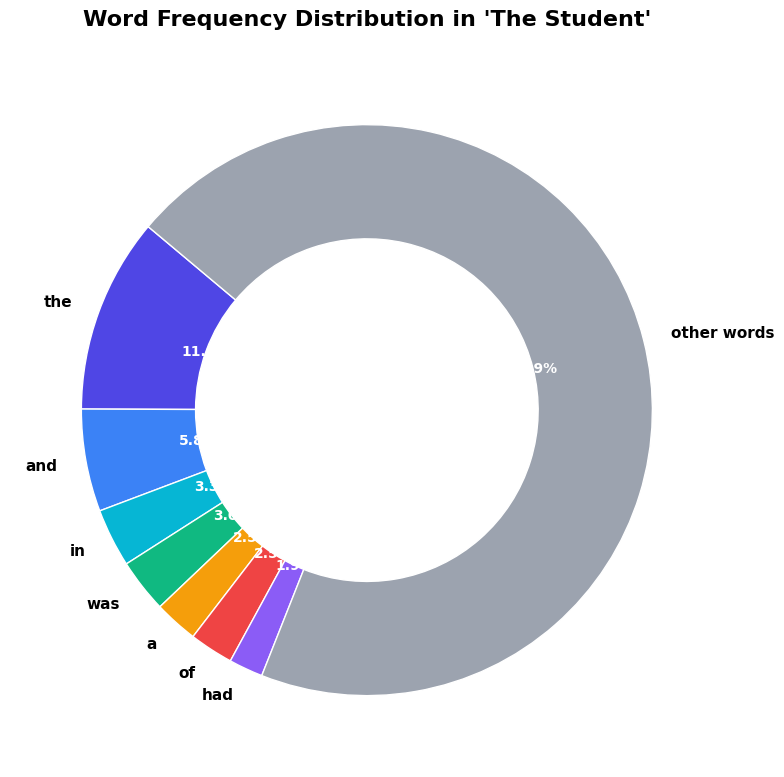

In [3]:
import matplotlib.pyplot as plt
from collections import Counter
import re

# Fallback text copy of Anton Chekhov's 'The Student'
full_text = """At first the weather was fine and still. The thrushes were calling, and in the swamps close by
something alive droned pitifully with a sound like blowing into an empty bottle. A snipe flew by,
and the shot aimed at it rang out with a gay, resounding note in the spring air. But when it
began to get dark in the forest a cold, penetrating wind blew inappropriately from the east, and
everything sank into silence. Needles of ice stretched across the pools, and it felt cheerless,
remote, and lonely in the forest. There was a whiff of winter.
Ivan Velikopolsky, the son of a sacristan, and a student of the clerical academy, returning home
from shooting, kept walking on the path by the water-logged meadows. His fingers were numb
and his face was burning with the wind. It seemed to him that the cold that had suddenly come
on had destroyed the order and harmony of things, that nature itself felt ill at ease, and that was
why the evening darkness was falling more rapidly than usual. All around it was deserted and
peculiarly gloomy. The only light was one gleaming in the widows’ gardens near the river; the
village, over three miles away, and everything in the distance all round was plunged in the cold
evening mist. The student remembered that, as he had left the house, his mother was sitting
barefoot on the floor in the entryway, cleaning the samovar, while his father lay on the stove
coughing; as it was Good Friday nothing had been cooked, and the student was terribly hungry.
And now, shrinking from the cold, he thought that just such a wind had blown in the days of
Rurik and in the time of Ivan the Terrible and Peter, and in their time there had been just the
same desperate poverty and hunger, the same thatched roofs with holes in them, ignorance,
misery, the same desolation around, the same darkness, the same feeling of oppression — all
these had existed, did exist, and would exist, and the lapse of a thousand years would make life
no better. And he did not want to go home."""

# 1. Clean and tokenize the fallback text to get actual frequencies
words = re.findall(r'\b\w+\b', full_text.lower())
word_counts = Counter(words)

# 2. Get the top 7 most common words and group the rest as 'Other'
top_n = 7
most_common = word_counts.most_common(top_n)

top_words = [word for word, count in most_common]
top_counts = [count for word, count in most_common]

other_count = len(words) - sum(top_counts)
top_words.append('other words')
top_counts.append(other_count)

# 3. Plot the pie chart
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#4f46e5', '#3b82f6', '#06b6d4', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6', '#9ca3af']

wedges, texts, autotexts = ax.pie(
    top_counts,
    labels=top_words,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(top_words)],
    wedgeprops=dict(width=0.4, edgecolor='w') # Donut-style chart
)

# Style the chart for better readability
plt.setp(texts, size=11, weight="bold")
plt.setp(autotexts, size=10, weight="bold", color="white")
ax.set_title("Word Frequency Distribution in 'The Student'", fontsize=16, weight="bold", pad=20)

plt.tight_layout()
plt.show()